
================ Training MLP on XOR ================
Epoch  2000 | Mean Squared Error Loss: 0.00984
Epoch  4000 | Mean Squared Error Loss: 0.00208
Epoch  6000 | Mean Squared Error Loss: 0.00112
Epoch  8000 | Mean Squared Error Loss: 0.00076
Epoch 10000 | Mean Squared Error Loss: 0.00057

MLP Successfully Converged!
Predictions:
[[0.023]
 [0.974]
 [0.974]
 [0.021]]


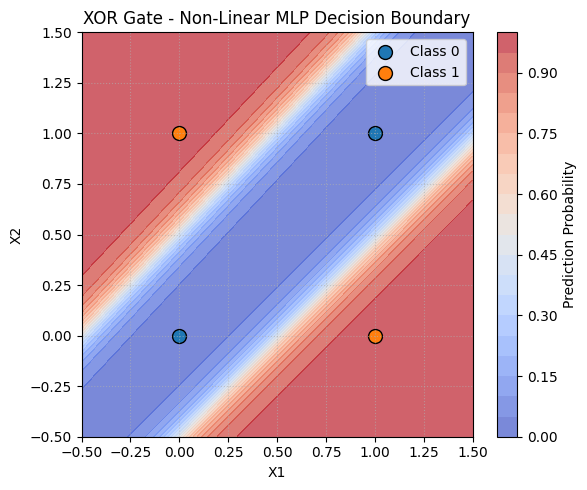

In [2]:
import numpy as np
import matplotlib.pyplot as plt

class MLP_XOR:
    def __init__(self, lr=0.5, epochs=10000):
        self.lr = lr
        self.epochs = epochs
        # Weights: Input(2) -> Hidden(2) -> Output(1)
        np.random.seed(42)
        self.W1 = np.random.uniform(-1, 1, (2, 2))
        self.b1 = np.zeros((1, 2))
        self.W2 = np.random.uniform(-1, 1, (2, 1))
        self.b2 = np.zeros((1, 1))

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def sigmoid_derivative(self, x):
        return x * (1 - x)

    def fit(self, X, y):
        y = y.reshape(-1, 1)
        print("\n================ Training MLP on XOR ================")

        for epoch in range(1, self.epochs + 1):
            # 1. Forward Pass
            hidden_input = np.dot(X, self.W1) + self.b1
            hidden_output = self.sigmoid(hidden_input)

            final_input = np.dot(hidden_output, self.W2) + self.b2
            final_output = self.sigmoid(final_input)

            # 2. Backpropagation
            error = y - final_output
            if epoch % 2000 == 0:
                loss = np.mean(np.square(error))
                print(f"Epoch {epoch:5d} | Mean Squared Error Loss: {loss:.5f}")

            d_output = error * self.sigmoid_derivative(final_output)
            error_hidden = d_output.dot(self.W2.T)
            d_hidden = error_hidden * self.sigmoid_derivative(hidden_output)

            # 3. Weight Updates
            self.W2 += hidden_output.T.dot(d_output) * self.lr
            self.b2 += np.sum(d_output, axis=0, keepdims=True) * self.lr
            self.W1 += X.T.dot(d_hidden) * self.lr
            self.b1 += np.sum(d_hidden, axis=0, keepdims=True) * self.lr

        print("\nMLP Successfully Converged!")
        print(f"Predictions:\n{np.round(final_output, 3)}")

    def plot_decision_boundary(self, X, y):
        # Create a dense grid to visualize non-linear boundary
        x_min, x_max = -0.5, 1.5
        y_min, y_max = -0.5, 1.5
        xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                             np.linspace(y_min, y_max, 200))

        grid_points = np.c_[xx.ravel(), yy.ravel()]

        # Forward pass on grid
        h = self.sigmoid(np.dot(grid_points, self.W1) + self.b1)
        Z = self.sigmoid(np.dot(h, self.W2) + self.b2)
        Z = Z.reshape(xx.shape)

        plt.figure(figsize=(6, 5))
        plt.contourf(xx, yy, Z, levels=20, cmap="coolwarm", alpha=0.7)
        plt.colorbar(label="Prediction Probability")

        for cl in np.unique(y):
            plt.scatter(X[y == cl, 0], X[y == cl, 1],
                        label=f'Class {cl}', s=100, edgecolors='k')

        plt.title("XOR Gate - Non-Linear MLP Decision Boundary")
        plt.xlabel("X1")
        plt.ylabel("X2")
        plt.legend()
        plt.grid(True, linestyle=":", alpha=0.6)
        plt.tight_layout()
        plt.show()

# Run MLP on XOR
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([0, 1, 1, 0])

mlp = MLP_XOR(lr=0.5, epochs=10000)
mlp.fit(X_xor, y_xor)
mlp.plot_decision_boundary(X_xor, y_xor)